In [23]:
import os
import torch

import numpy                        as     np
import matplotlib.pyplot            as     plt
import torchvision.transforms       as     transforms

from   pytorch_grad_cam             import GradCAM
from   PIL                          import Image
from   pytorch_grad_cam.utils.image import show_cam_on_image
from   utils.model_execution        import setup_uni_model, setup_resnet_model

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


# Model Interpretability

In [3]:
def patch_attention_to_return_weights(model):
    def new_forward(self, x, attn_mask=None):
        B, N, C                = x.shape
        qkv                    = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v                = qkv.unbind(0)
        
        q                      = self.q_norm(q)
        k                      = self.k_norm(k)
        
        attn                   = (q @ k.transpose(-2, -1)) * self.scale
        attn                   = attn.softmax(dim=-1)
        attn_weights           = attn.clone()
        attn                   = self.attn_drop(attn)
        
        x                      = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x                      = self.proj(x)
        x                      = self.proj_drop(x)
        
        self.last_attn_weights = attn_weights
        
        return x
    
    for block in model.blocks:
        block.attn.forward = new_forward.__get__(block.attn, type(block.attn))
    
    return model

In [ ]:
def rollout(attentions, discard_ratio=0.9, head_fusion='mean', num_prefix_tokens=1):
    result = torch.eye(attentions[0].size(-1), device=attentions[0].device)

    with torch.no_grad():
        for attention in attentions:
            if head_fusion == 'mean':
                attention_heads_fused = attention.mean(dim=1) 
            elif head_fusion == "max":
                attention_heads_fused = attention.amax(dim=1)
            elif head_fusion == "min":
                attention_heads_fused = attention.amin(dim=1)
            
            attention_heads_fused = attention_heads_fused.squeeze(0) 
            
            I                     = torch.eye(attention_heads_fused.size(-1), device=attention_heads_fused.device)
            a                     = (attention_heads_fused + 1.0 * I) / 2
            a                     = a / a.sum(dim=-1, keepdim=True)
            result                = torch.matmul(a, result)
    
    mask = result[0, num_prefix_tokens:]
    width = int(mask.size(-1) ** 0.5)
    mask = mask.reshape(width, width).cpu().numpy()
    mask = mask / np.max(mask)
    
    return mask

In [5]:
def apply_mask(image, mask, color=(1, 0, 0), alpha=0.5):
    mask         = mask[:, :, np.newaxis]
    mask         = np.repeat(mask, 3, axis=2)
    color        = np.array(color)
    masked_image = image * (1 - alpha * mask) + alpha * mask * color

    return np.clip(masked_image, 0, 1)


In [6]:
def load_and_preprocess_image(img_path, transform):
    img_pil      = Image.open(img_path).convert('RGB')
    input_tensor = transform(img_pil).unsqueeze(0)
    
    return img_pil, input_tensor

In [7]:
def tensor_to_img_np(input_tensor, mean, std):
    img_np = input_tensor[0].cpu().numpy().transpose(1, 2, 0)
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    return img_np

In [8]:
def get_fma_attention_mask(fma_model, input_tensor, rollout):
    with torch.no_grad():
        _ = fma_model(input_tensor.to(device))

    attention_list = []

    for block in fma_model.blocks:
        if hasattr(block.attn, 'last_attn_weights'):
            attention_list.append(block.attn.last_attn_weights)

    rollout_mask = rollout(attention_list)
    attn_resized = Image.fromarray((rollout_mask * 255).astype(np.uint8)).resize((224, 224), Image.BICUBIC)
    attn_resized = np.array(attn_resized) / 255.0
    
    return attn_resized

In [9]:
def get_dla_gradcam(cam_dla, input_tensor, img_np):
    grayscale_cam_dla = cam_dla(input_tensor=input_tensor.to(device))
    visualization_dla = show_cam_on_image(img_np, grayscale_cam_dla[0], use_rgb=True)
    
    return visualization_dla

In [10]:
fma_model = setup_uni_model(num_classes=6)
fma_model.load_state_dict(torch.load('./models/fma_multi.pth', map_location=device))
fma_model.to(device)
fma_model.eval()
fma_model = patch_attention_to_return_weights(fma_model)

In [ ]:
dla_model = setup_resnet_model(num_classes=6)
dla_model.load_state_dict(torch.load('./models/dla_multi.pth', map_location=device))
dla_model.to(device)
dla_model.eval()

In [17]:
target_layers = [dla_model.layer4[-1]]
cam_dla       = GradCAM(model=dla_model, target_layers=target_layers)

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])



In [19]:
img_paths = [
    './data/training/fold/training_fold_9.png',
    './data/training/fold/training_fold_10.png',
    './data/training/fold/training_fold_11.png',
    './data/training/fold/training_fold_12.png'
]

In [20]:
fma_imgs, fma_heatmaps = [], []
dla_imgs, dla_heatmaps = [], []

In [21]:
for img_path in img_paths:
    img_pil, input_tensor = load_and_preprocess_image(img_path, transform)
    img_np                = tensor_to_img_np(input_tensor, mean, std)

    fma_imgs.append(img_np)
    fma_heatmaps.append(get_fma_attention_mask(fma_model, input_tensor, rollout))
    dla_imgs.append(img_np)
    dla_heatmaps.append(get_dla_gradcam(cam_dla, input_tensor, img_np))

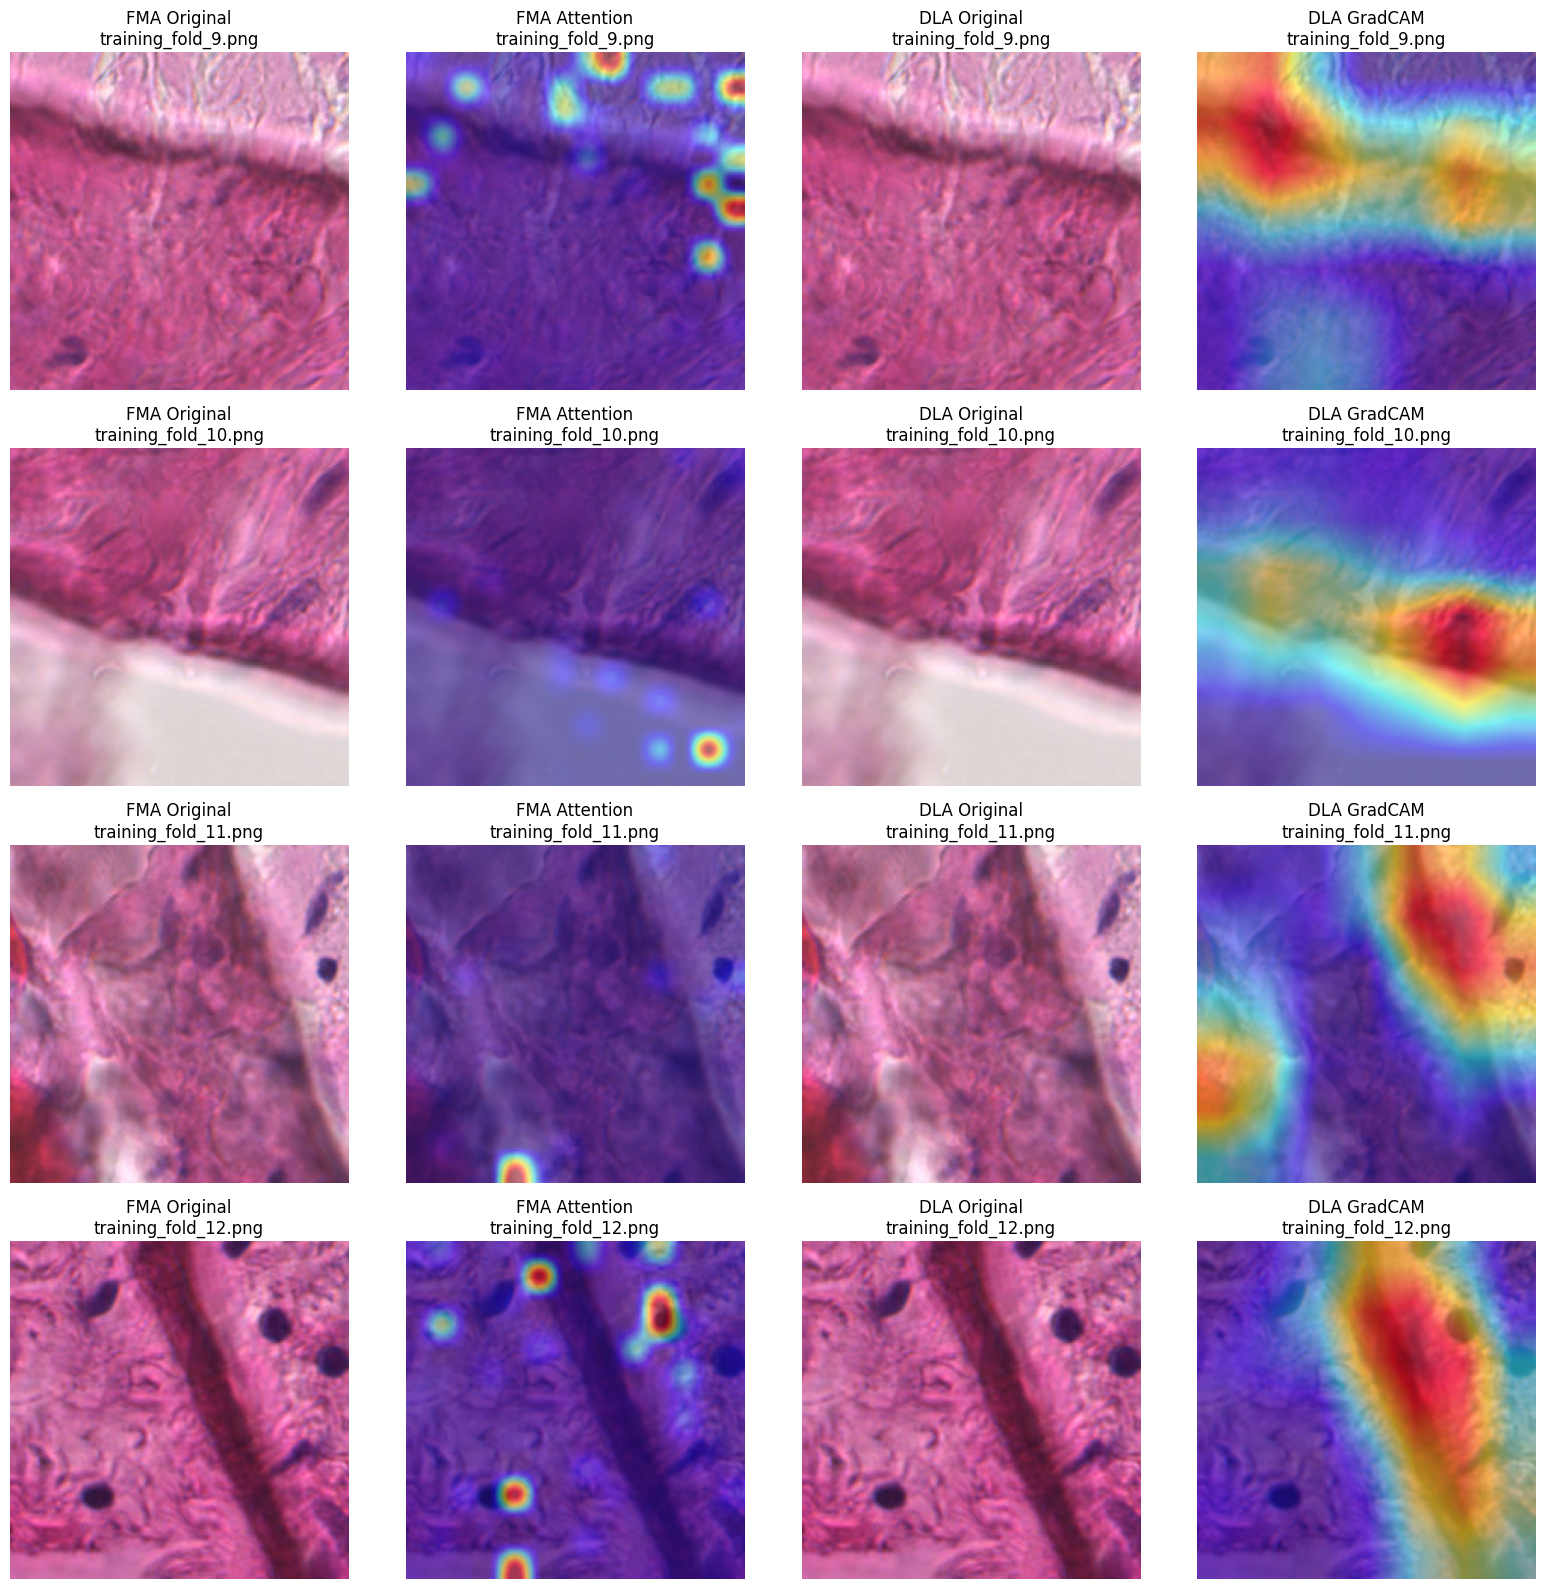

In [24]:
plt.figure(figsize=(16, 16))

for i in range(4):
    file_name = os.path.basename(img_paths[i])

    plt.subplot(4, 4, i*4 + 1)
    plt.imshow(fma_imgs[i])
    plt.title(f'FMA Original\n{file_name}')
    plt.axis('off')

    plt.subplot(4, 4, i*4 + 2)
    plt.imshow(fma_imgs[i])
    plt.imshow(fma_heatmaps[i], cmap='jet', alpha=0.5)
    plt.title(f'FMA Attention\n{file_name}')
    plt.axis('off')

    plt.subplot(4, 4, i*4 + 3)
    plt.imshow(dla_imgs[i])
    plt.title(f'DLA Original\n{file_name}')
    plt.axis('off')

    plt.subplot(4, 4, i*4 + 4)
    plt.imshow(dla_heatmaps[i])
    plt.title(f'DLA GradCAM\n{file_name}')
    plt.axis('off')
    
plt.tight_layout()
plt.show()